In [1]:
import numpy as np
import pandas as pd

from scformer.utils import *
from scformer.model import *
from warnings import filterwarnings
import random
import os
import torch
import torch.cuda as cuda
from scipy import sparse
import scanpy as sc
import anndata as ad

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

# Mouse retina data

In [6]:
gene_cell = ad.read_mtx('data/mouse_retina/Gene_Cell.mtx')
gene_names = pd.read_csv('data/mouse_retina/Gene_names.tsv', sep='\t', header=None)
true_label = pd.read_csv('data/mouse_retina/Cell_type.tsv', sep='\t', header=None)

gene_cell.obs_names = gene_names[0]

RNA_matrix = gene_cell.X

cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]
cell_num

9383

In [7]:
initial_pre = initial_clustering(RNA_matrix)

	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
         Falling back to preprocessing with `sc.pp.pca` and default params.


In [8]:
cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix)
n_batch = len(indices)

Partitioning the data into batches. Please wait...


Processing Batches: 100%|██████████| 313/313 [00:39<00:00,  7.89it/s]


In [9]:
device = torch.device("cuda" if cuda.is_available() else "cpu")
node_model = NodeDimensionReduction(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                                    n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                                    num_relations=2, epochs=100)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch)

The training process for the NodeDimensionReduction model has started. Please wait.


100%|██████████| 100/100 [37:23<00:00, 22.44s/it]

The training for the NodeDimensionReduction model has been completed.


In [10]:
ScFormer_model = ScFormer(gnn=gnn, h=h, labsm=0.1, n_hid=104, n_batch=n_batch, device=device, lr=0.0005, wd=0.1,
                          num_epochs=50)
ScFormer_gnn, _, _, _ = ScFormer_model.train_model(indices=indices, RNA_matrix=RNA_matrix, ini_p1=ini_p1)

The training process for the scformer model has started. Please wait.
Forward pass started.


Epochs: 100%|██████████| 50/50 [22:19<00:00, 26.78s/it]

The training for the scformer model has been completed.
The training for the scformer model has been completed.


In [12]:
ScFormer_result = ScFormer_pred(RNA_matrix, gnn=ScFormer_gnn, indices=indices,
                                nodes_id=Node_Ids, device=device)
# Save numpy arrays to files
output_file = 'data/mouse_retina/output'
np.save(output_file + "/Node_Ids.npy", Node_Ids)
np.save(output_file + "/pred.npy", ScFormer_result['pred_label'])
np.save(output_file + "/cell_embedding.npy", ScFormer_result['cell_embedding'])

Prediction Batches: 100%|██████████| 313/313 [00:12<00:00, 25.31it/s]


In [14]:
pred_label = ScFormer_result['pred_label']
p_score, labels = purity_score(np.array(true_label), pred_label)

In [43]:
e = Entropy(np.array(pred_label, dtype='int64'), np.array(labels, dtype='int64').reshape(-1))

In [56]:
print("purity:%.4f" % p_score)
print("NMI:%.4f" % normalized_mutual_info_score(true_label.values.flatten(), np.array(labels, dtype='int64').reshape(-1)))
print("Entropy:%.4f" % e)

purity:0.7158
NMI:1.0000
Entropy:1.2627


In [62]:
adata =  ad.AnnData(RNA_matrix.transpose(), dtype='int32')[Node_Ids]
adata.var_names=gene_names[0]
adata

AnnData object with n_obs × n_vars = 9383 × 6198

In [66]:
adata.obs['pred_type'] = np.array(pred_label)
adata.obs['pred_type'] = adata.obs['pred_type'].astype("category")
adata

AnnData object with n_obs × n_vars = 9383 × 6198
    obs: 'pred_type'

In [67]:
adata.obs['true_label'] = np.array(true_label)
adata.obs['true_label'] = adata.obs['true_label'].astype("category")
adata.obs

,pred_type,true_label
4924,0,BC4
5093,1,BC2
2172,11,rod
3505,0,rod
2577,0,BC2
...,...,...
3098,6,BC10
1044,1,rod
738,0,rod
4270,0,rod


In [69]:
adata.obsm['cell_emb'] = ScFormer_result['cell_embedding']

In [70]:
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)

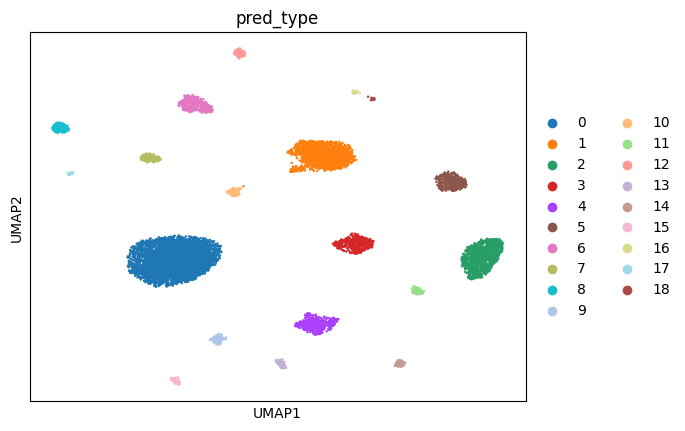

In [71]:
sc.pl.umap(adata, color=['pred_type'], show=True)

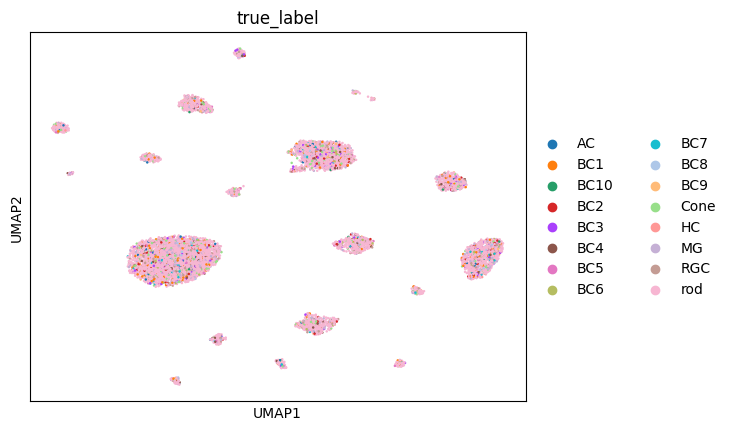

In [72]:
sc.pl.umap(adata, color=['true_label'], show=True)